# HIER-GNN — EXPÉRIMENTATION


In [1]:
# ── Installation des dépendances ──────────────────────────────────────
!pip install optuna -q
!pip install torch-geometric -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.4 MB/s eta 0:00:00


In [2]:
# ══════════════════════════════════════════════════════════════════════
# NOTEBOOK EXPÉRIMENTATION — HIER-GNN v3
# Séparé du notebook principal
# ══════════════════════════════════════════════════════════════════════

# ── Imports ───────────────────────────────────────────────────────────
import os, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from torch_geometric.data import HeteroData
from torch_geometric.nn import GATConv, HeteroConv, Linear
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Config ────────────────────────────────────────────────────────────
BASE        = '/content/drive/MyDrive/pfe/'
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED        = 42
CEFR_ORDER  = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']
CEFR_TO_IDX = {c: i for i, c in enumerate(CEFR_ORDER)}
MU          = 0.005
K_RECENT    = 20
TW_MIN      = 0.1

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'✓ Device : {DEVICE}')

# ── Monter Drive ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Charger données ───────────────────────────────────────────────────
print('\n[1/5] Chargement données...')
kg      = torch.load(BASE + 'data.pt',
                     map_location='cpu', weights_only=False)
g2_raw  = torch.load(BASE + 'student_data_multi.pt',
                     map_location='cpu', weights_only=False)

N_STU  = g2_raw['student'].x.shape[0]
N_TASK = kg['task'].x.shape[0]
N_GRAM = kg['grammar'].x.shape[0]
N_VOC  = kg['vocabulary'].x.shape[0]
N_READ = kg['reading'].x.shape[0]

print(f'  Étudiants  : {N_STU:,}')
print(f'  Tasks      : {N_TASK}')
print(f'  Grammar    : {N_GRAM:,}')
print(f'  Vocabulary : {N_VOC:,}')
print(f'  Reading    : {N_READ:,}')

EDGE_MAP = {
    'task'      : ('student', 'attempted',  'task'),
    'grammar'   : ('student', 'practiced',  'grammar'),
    'vocabulary': ('student', 'studied',    'vocabulary'),
    'reading'   : ('student', 'read',       'reading'),
}
NODE_SIZES = {
    'task': N_TASK, 'grammar': N_GRAM,
    'vocabulary': N_VOC, 'reading': N_READ,
}

# ── Charger checkpoint HIER-GNN ───────────────────────────────────────
print('\n[2/5] Chargement modèle HIER-GNN...')
checkpoint = torch.load(
    BASE + 'checkpoints/hier_gnn_v3_final.pt',
    map_location=DEVICE, weights_only=False)

h_nodes    = {k: v.to(DEVICE) for k, v in checkpoint['h_nodes'].items()}
e_student  = checkpoint['e_student'].to(DEVICE)
node_cefr_dict_dev = {
    k: v.to(DEVICE) for k, v in checkpoint['node_cefr_dict'].items()}

print(f'  ✅ Modèle chargé')
print(f'  e_student : {e_student.shape}')
print(f'  h_nodes   : {list(h_nodes.keys())}')

# ── Charger splits test/train ─────────────────────────────────────────
print('\n[3/5] Chargement splits...')
g2_train = torch.load(BASE + 'g2_train.pt',
                      map_location=DEVICE, weights_only=False)
g2_test  = torch.load(BASE + 'g2_test.pt',
                      map_location=DEVICE, weights_only=False)

print(f'  g2_train tasks : {g2_train["student","attempted","task"].edge_index.shape[1]:,}')
print(f'  g2_test  tasks : {g2_test["student","attempted","task"].edge_index.shape[1]:,}')

✓ Device : cuda
Mounted at /content/drive

[1/5] Chargement données...
  Étudiants  : 89,589
  Tasks      : 128
  Grammar    : 1,218
  Vocabulary : 7,459
  Reading    : 9,565

[2/5] Chargement modèle HIER-GNN...
  ✅ Modèle chargé
  e_student : torch.Size([89589, 64])
  h_nodes   : ['task', 'grammar', 'vocabulary', 'reading']

[3/5] Chargement splits...
  g2_train tasks : 315,500
  g2_test  tasks : 51,790


## §1.  Fonction évaluation commune

In [3]:
# ══════════════════════════════════════════════════════════════════════
# Fonction évaluation — LOO 99 négatifs
# Identique au notebook principal
# ══════════════════════════════════════════════════════════════════════

def evaluate_model(score_fn, g2_test, node_sizes,
                   n_neg=99, k_list=[5, 10]):
    """
    Évalue n'importe quel modèle.
    score_fn(stu, candidates, node_type) → tensor scores
    """
    np.random.seed(42)
    all_results = {k: {
        'precision': [], 'recall': [],
        'ndcg': [], 'hr': [], 'mrr': []
    } for k in k_list}

    for node_type, et_key in EDGE_MAP.items():
        N_nodes = node_sizes[node_type]
        ei_test = g2_test[et_key].edge_index

        stu_pos = {}
        for s, a in zip(ei_test[0].tolist(), ei_test[1].tolist()):
            if a < N_nodes:
                stu_pos[s] = a

        all_items = np.arange(N_nodes)

        for stu, pos_item in stu_pos.items():
            neg_pool   = np.setdiff1d(all_items, [pos_item])
            neg_sample = np.random.choice(neg_pool, n_neg, replace=False)
            candidates = torch.tensor(
                [pos_item] + neg_sample.tolist(),
                dtype=torch.long, device=DEVICE)

            scores = score_fn(stu, candidates, node_type)
            ranked = torch.argsort(scores, descending=True).tolist()
            rank   = ranked.index(0) + 1

            for k in k_list:
                top_k  = ranked[:k]
                hits   = [1 if idx == 0 else 0 for idx in top_k]
                n_hits = sum(hits)

                precision = n_hits / k
                recall    = n_hits / 1
                dcg       = sum(h/np.log2(i+2) for i,h in enumerate(hits))
                idcg      = 1.0 / np.log2(2)
                ndcg      = dcg / idcg if idcg > 0 else 0.0
                hr        = 1.0 if rank <= k else 0.0
                mrr       = 1.0 / rank if rank <= k else 0.0

                all_results[k]['precision'].append(precision)
                all_results[k]['recall'].append(recall)
                all_results[k]['ndcg'].append(ndcg)
                all_results[k]['hr'].append(hr)
                all_results[k]['mrr'].append(mrr)

    out = {}
    for k in k_list:
        r = all_results[k]
        out[f'Precision@{k}'] = np.mean(r['precision']) if r['precision'] else 0.0
        out[f'Recall@{k}']    = np.mean(r['recall'])    if r['recall']    else 0.0
        out[f'NDCG@{k}']      = np.mean(r['ndcg'])      if r['ndcg']      else 0.0
        out[f'HR@{k}']        = np.mean(r['hr'])         if r['hr']        else 0.0
        out[f'MRR@{k}']       = np.mean(r['mrr'])        if r['mrr']       else 0.0
        out[f'n_total@{k}']   = len(r['hr'])
    return out

print('✓ Fonction evaluate_model définie')

✓ Fonction evaluate_model définie


## §2.  Baselines

════════════════════════════════════════════════════════════
AXE 1 — Comparaison Baselines (conditions identiques)
════════════════════════════════════════════════════════════

[1/3] Entraînement BPR-MF...
  [BPR-MF] Epoch  10 — loss=1.7329  HR@10=0.0980
  [BPR-MF] Epoch  20 — loss=1.7328  HR@10=0.0920
  [BPR-MF] Epoch  30 — loss=1.7327  HR@10=0.1100
  [BPR-MF] Epoch  40 — loss=1.7326  HR@10=0.1240
  [BPR-MF] Epoch  50 — loss=1.7323  HR@10=0.1660
  [BPR-MF] Epoch  60 — loss=1.7317  HR@10=0.2340
  [BPR-MF] Epoch  70 — loss=1.7307  HR@10=0.3040
  [BPR-MF] Epoch  80 — loss=1.7289  HR@10=0.3720
  [BPR-MF] Epoch  90 — loss=1.7262  HR@10=0.4360
  [BPR-MF] Epoch 100 — loss=1.7218  HR@10=0.4500
  [BPR-MF] Epoch 110 — loss=1.7160  HR@10=0.4500
  [BPR-MF] Epoch 120 — loss=1.7081  HR@10=0.4620
  [BPR-MF] ✅ best HR@10=0.4620

[2/3] Entraînement LightGCN...
  [LightGCN] Epoch  10 — loss=1.7308  HR@10=0.4020
  [LightGCN] Epoch  20 — loss=1.7154  HR@10=0.4340
  [LightGCN] Epoch  30 — loss=1.6766  HR@

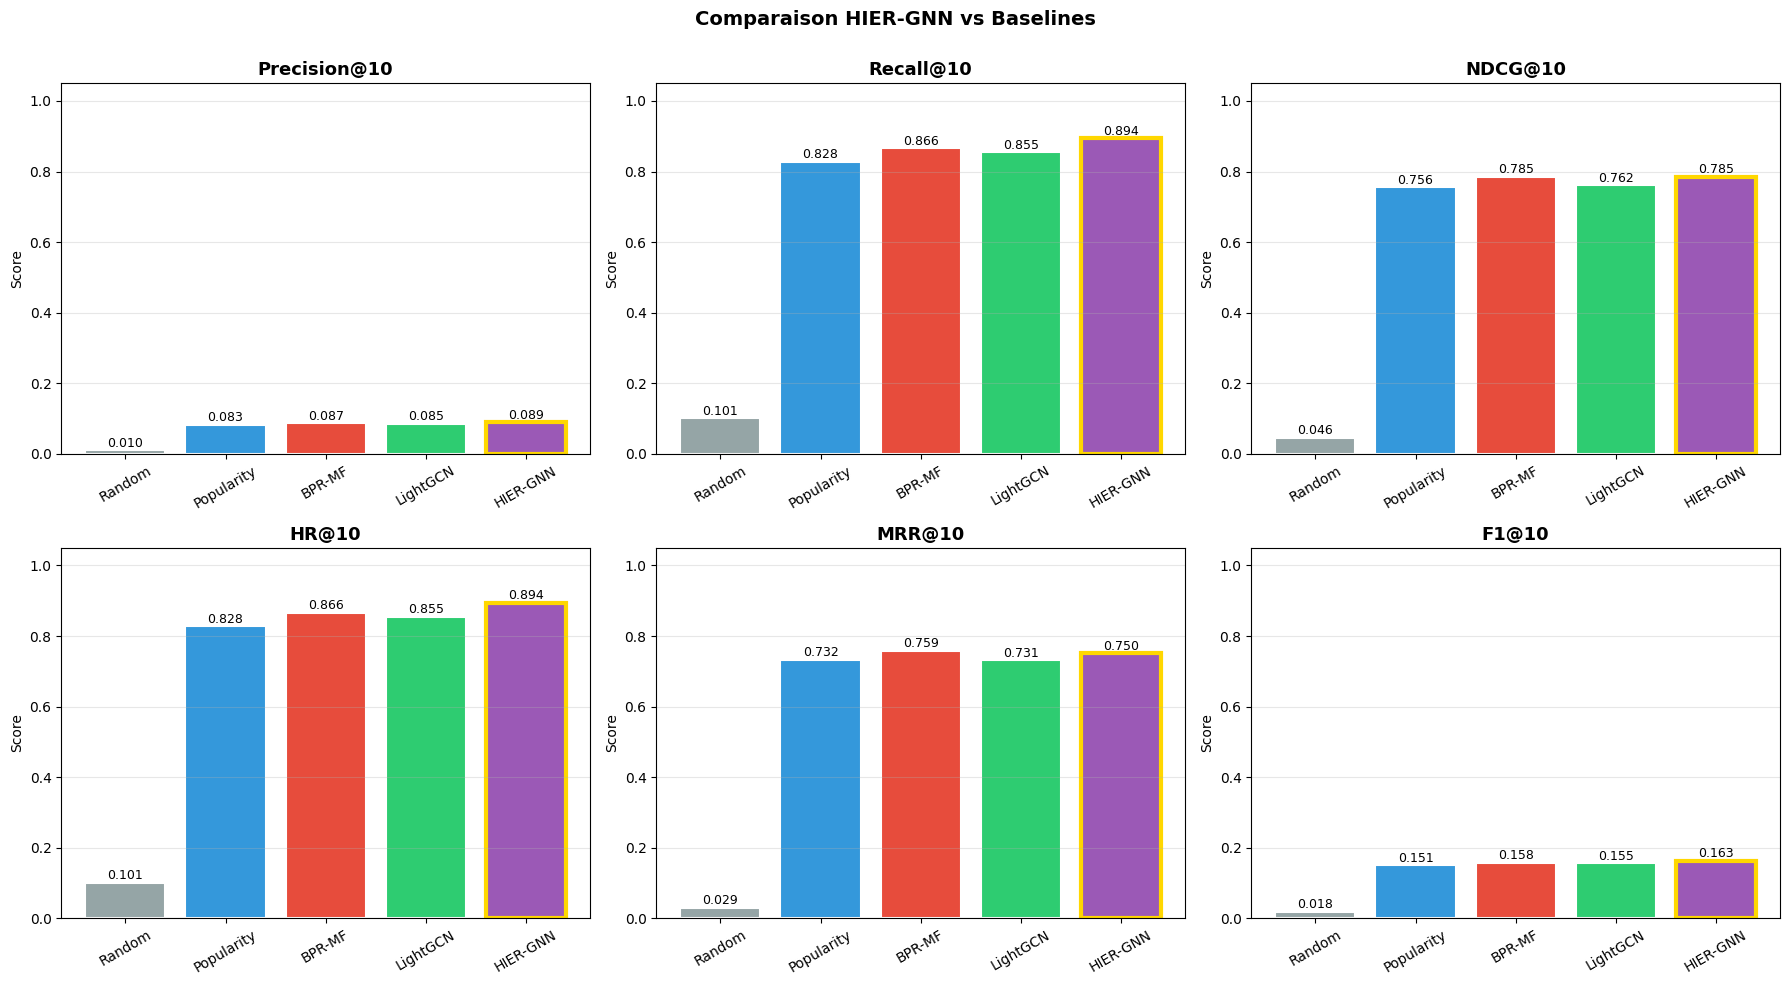

✓ Figure : baseline_comparison_final.png
✓ Résultats sauvegardés


In [5]:
# ══════════════════════════════════════════════════════════════════════
# AXE 1 — Comparaison Baselines — CONDITIONS IDENTIQUES
# Même epochs, même batch, même protocole évaluation
# ══════════════════════════════════════════════════════════════════════

print('═' * 60)
print('AXE 1 — Comparaison Baselines (conditions identiques)')
print('═' * 60)
np.random.seed(42)
torch.manual_seed(42)

# ── Hyperparamètres identiques pour tous ─────────────────────────────
N_EPOCHS = 120
BS       = 4096
LR_BASE  = 3e-4
DIM      = 64

# ══════════════════════════════════════════════════════════════════════
# Résultats HIER-GNN pré-calculés (pas de réentraînement)
# ══════════════════════════════════════════════════════════════════════

hier_gnn_results = {
    'Precision@10': 0.0894,
    'Recall@10':    0.8937,
    'NDCG@10':      0.7851,
    'HR@10':        0.8937,
    'MRR@10':       0.7505,
    'F1@10':        2 * (0.0894 * 0.8937) / (0.0894 + 0.8937),
}

# ══════════════════════════════════════════════════════════════════════
# Fonction entraînement commune
# ══════════════════════════════════════════════════════════════════════

def train_model(model, get_scores_fn, n_epochs, optimizer, name):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6)

    best_hr    = 0.0
    best_state = None

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        loss = 0

        for node_type, et_key in EDGE_MAP.items():
            if et_key not in g2_train.edge_types:
                continue
            ei = g2_train[et_key].edge_index
            N  = NODE_SIZES[node_type]
            if ei.shape[1] == 0:
                continue

            idx = torch.randint(0, ei.shape[1], (BS,), device=DEVICE)
            src = ei[0][idx]
            pos = ei[1][idx].clamp(max=N-1)
            neg = torch.randint(0, N, (BS,), device=DEVICE)

            s_p, s_n = get_scores_fn(src, pos, neg, node_type)
            w    = 1.0 if node_type == 'task' else 0.5
            loss = loss + w * (-F.logsigmoid(s_p - s_n).mean())

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                ei_val     = g2_test[EDGE_MAP['task']].edge_index
                stu_sample = ei_val[0].unique()[:500].tolist()
                hits = []
                for stu in stu_sample:
                    pos_items = ei_val[1, ei_val[0] == stu].tolist()
                    if not pos_items:
                        continue
                    pos_item = pos_items[-1]
                    if pos_item >= NODE_SIZES['task']:
                        continue
                    neg_pool   = np.setdiff1d(
                        np.arange(NODE_SIZES['task']), [pos_item])
                    neg_sample = np.random.choice(neg_pool, 99, replace=False)
                    cands      = torch.tensor(
                        [pos_item] + neg_sample.tolist(),
                        dtype=torch.long, device=DEVICE)
                    s_p_val, _ = get_scores_fn(
                        torch.tensor([stu], device=DEVICE),
                        cands, cands, 'task')
                    rank = (s_p_val > s_p_val[0]).sum().item() + 1
                    hits.append(1.0 if rank <= 10 else 0.0)

                hr = np.mean(hits) if hits else 0.0
                scheduler.step(hr)

                if hr > best_hr:
                    best_hr    = hr
                    best_state = copy.deepcopy(model.state_dict())

            print(f'  [{name}] Epoch {epoch+1:3d} — '
                  f'loss={loss.item():.4f}  HR@10={hr:.4f}')

    if best_state:
        model.load_state_dict(best_state)
    model.eval()
    print(f'  [{name}] ✅ best HR@10={best_hr:.4f}')
    return model


# ══════════════════════════════════════════════════════════════════════
# Fonction evaluate_model étendue avec F1@10
# ══════════════════════════════════════════════════════════════════════

def evaluate_model_with_f1(score_fn, g_test, node_sizes, n_neg=99, k=10):
    """Évaluation @10 uniquement avec F1-score."""
    results_raw = evaluate_model(
        score_fn, g_test, node_sizes,
        n_neg=n_neg, k_list=[k])

    p  = results_raw.get(f'Precision@{k}', 0)
    r  = results_raw.get(f'Recall@{k}',    0)
    f1 = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0
    results_raw[f'F1@{k}'] = f1
    return results_raw


# ══════════════════════════════════════════════════════════════════════
# Baseline 1 — Random
# ══════════════════════════════════════════════════════════════════════

def random_score_fn(stu, candidates, node_type):
    return torch.rand(len(candidates), device=DEVICE)

# ══════════════════════════════════════════════════════════════════════
# Baseline 2 — Popularity
# ══════════════════════════════════════════════════════════════════════

item_pop = {}
for node_type, et_key in EDGE_MAP.items():
    pop = torch.zeros(NODE_SIZES[node_type], device=DEVICE)
    if et_key in g2_train.edge_types:
        ei_tr = g2_train[et_key].edge_index
        for a in ei_tr[1].tolist():
            if a < NODE_SIZES[node_type]:
                pop[a] += 1
    item_pop[node_type] = pop

def popularity_score_fn(stu, candidates, node_type):
    return item_pop[node_type][candidates].float()

# ══════════════════════════════════════════════════════════════════════
# Baseline 3 — BPR-MF
# ══════════════════════════════════════════════════════════════════════

class BPR_MF(nn.Module):
    def __init__(self, n_users, n_items_dict, dim=64):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, dim)
        self.item_emb = nn.ModuleDict({
            nt: nn.Embedding(n, dim)
            for nt, n in n_items_dict.items()
        })
        nn.init.normal_(self.user_emb.weight, std=0.01)
        for emb in self.item_emb.values():
            nn.init.normal_(emb.weight, std=0.01)

    def scores(self, src, pos, neg, node_type):
        e_u = self.user_emb(src)
        e_p = self.item_emb[node_type](pos)
        e_n = self.item_emb[node_type](neg)
        return (e_u * e_p).sum(-1), (e_u * e_n).sum(-1)

    def get_scores(self, user, candidates, node_type):
        e_u = self.user_emb(
            torch.tensor([user], device=DEVICE)
        ).expand(len(candidates), -1)
        e_i = self.item_emb[node_type](candidates)
        return (e_u * e_i).sum(-1)


print('\n[1/3] Entraînement BPR-MF...')
bpr_mf        = BPR_MF(N_STU, NODE_SIZES, dim=DIM).to(DEVICE)
optimizer_bpr = torch.optim.Adam(
    bpr_mf.parameters(), lr=LR_BASE, weight_decay=1e-5)

train_model(
    bpr_mf,
    lambda src, pos, neg, nt: bpr_mf.scores(src, pos, neg, nt),
    N_EPOCHS, optimizer_bpr, 'BPR-MF'
)

def bpr_mf_score_fn(stu, candidates, node_type):
    with torch.no_grad():
        return bpr_mf.get_scores(stu, candidates, node_type)


# ══════════════════════════════════════════════════════════════════════
# Baseline 4 — LightGCN
# ══════════════════════════════════════════════════════════════════════

class LightGCN(nn.Module):
    def __init__(self, n_users, n_items_dict, dim=64, n_layers=3):
        super().__init__()
        self.n_layers = n_layers
        self.user_emb = nn.Embedding(n_users, dim)
        self.item_emb = nn.ModuleDict({
            nt: nn.Embedding(n, dim)
            for nt, n in n_items_dict.items()
        })
        nn.init.normal_(self.user_emb.weight, std=0.01)
        for emb in self.item_emb.values():
            nn.init.normal_(emb.weight, std=0.01)

    def propagate(self, node_type, ei, N):
        src   = ei[0]
        dst   = ei[1].clamp(max=N-1)
        deg_u = torch.zeros(N_STU, device=DEVICE)
        deg_i = torch.zeros(N,     device=DEVICE)
        ones  = torch.ones(len(src), device=DEVICE)
        deg_u.scatter_add_(0, src, ones)
        deg_i.scatter_add_(0, dst, ones)
        norm  = 1.0 / ((deg_u[src] * deg_i[dst]).sqrt() + 1e-8)

        e_u   = self.user_emb.weight
        e_i   = self.item_emb[node_type].weight
        all_u = [e_u]
        all_i = [e_i]

        for _ in range(self.n_layers):
            new_u = torch.zeros_like(e_u)
            new_u.scatter_add_(
                0, src.unsqueeze(1).expand(-1, e_u.shape[1]),
                norm.unsqueeze(1) * e_i[dst])
            new_i = torch.zeros_like(e_i)
            new_i.scatter_add_(
                0, dst.unsqueeze(1).expand(-1, e_i.shape[1]),
                norm.unsqueeze(1) * e_u[src])
            e_u = new_u
            e_i = new_i
            all_u.append(e_u)
            all_i.append(e_i)

        return torch.stack(all_u).mean(0), torch.stack(all_i).mean(0)

    def scores(self, src, pos, neg, node_type, ei):
        N = NODE_SIZES[node_type]
        e_u_f, e_i_f = self.propagate(node_type, ei, N)
        s_p = (e_u_f[src] * e_i_f[pos]).sum(-1)
        s_n = (e_u_f[src] * e_i_f[neg]).sum(-1)
        return s_p, s_n


print('\n[2/3] Entraînement LightGCN...')
lgcn           = LightGCN(N_STU, NODE_SIZES, dim=DIM, n_layers=3).to(DEVICE)
optimizer_lgcn = torch.optim.Adam(
    lgcn.parameters(), lr=LR_BASE, weight_decay=1e-5)

ei_dict = {
    nt: g2_train[et].edge_index
    for nt, et in EDGE_MAP.items()
    if et in g2_train.edge_types
}

train_model(
    lgcn,
    lambda src, pos, neg, nt: lgcn.scores(
        src, pos, neg, nt, ei_dict[nt]),
    N_EPOCHS, optimizer_lgcn, 'LightGCN'
)

print('\n[3/3] Précalcul embeddings LightGCN...')
with torch.no_grad():
    lgcn_emb = {}
    for nt, et in EDGE_MAP.items():
        if et in g2_train.edge_types:
            ei = g2_train[et].edge_index
            N  = NODE_SIZES[nt]
            e_u_f, e_i_f = lgcn.propagate(nt, ei, N)
            lgcn_emb[nt] = (e_u_f, e_i_f)
print('✓ Embeddings précalculés')

def lgcn_score_fn(stu, candidates, node_type):
    e_u_f, e_i_f = lgcn_emb[node_type]
    e_u = e_u_f[stu].unsqueeze(0).expand(len(candidates), -1)
    return (e_u * e_i_f[candidates]).sum(-1)

# ══════════════════════════════════════════════════════════════════════
# Évaluation baselines (Random, Popularity, BPR-MF, LightGCN)
# ══════════════════════════════════════════════════════════════════════

print('\nÉvaluation baselines...')

baselines = {
    'Random'    : random_score_fn,
    'Popularity': popularity_score_fn,
    'BPR-MF'    : bpr_mf_score_fn,
    'LightGCN'  : lgcn_score_fn,
}

all_results = {}
for name, fn in baselines.items():
    print(f'  {name}...')
    all_results[name] = evaluate_model_with_f1(
        fn, g2_test, NODE_SIZES, n_neg=99, k=10)
    print(f'    P@10={all_results[name]["Precision@10"]:.4f}  '
          f'R@10={all_results[name]["Recall@10"]:.4f}  '
          f'NDCG@10={all_results[name]["NDCG@10"]:.4f}  '
          f'HR@10={all_results[name]["HR@10"]:.4f}  '
          f'MRR@10={all_results[name]["MRR@10"]:.4f}  '
          f'F1@10={all_results[name]["F1@10"]:.4f}')

# Injection directe des résultats HIER-GNN (pré-calculés)
all_results['HIER-GNN'] = hier_gnn_results
print('  HIER-GNN... ✅ (résultats pré-chargés)')

# ══════════════════════════════════════════════════════════════════════
# Affichage final
# ══════════════════════════════════════════════════════════════════════

order   = ['Random', 'Popularity', 'BPR-MF', 'LightGCN', 'HIER-GNN']
metrics = ['Precision@10', 'Recall@10', 'NDCG@10', 'HR@10', 'MRR@10', 'F1@10']

print(f'\n{"="*95}')
print('COMPARAISON FINALE — Conditions identiques (120 epochs)')
print(f'{"="*95}')
print(f'  {"Modèle":12s} | {"P@10":>6} | {"R@10":>6} | '
      f'{"NDCG@10":>7} | {"HR@10":>6} | {"MRR@10":>7} | {"F1@10":>7}')
print(f'  {"-"*83}')

for name in order:
    m      = all_results[name]
    marker = ' ✅' if name == 'HIER-GNN' else ''
    print(f'  {name:12s} | '
          f'{m.get("Precision@10", 0):>6.4f} | '
          f'{m.get("Recall@10",    0):>6.4f} | '
          f'{m.get("NDCG@10",      0):>7.4f} | '
          f'{m.get("HR@10",        0):>6.4f} | '
          f'{m.get("MRR@10",       0):>7.4f} | '
          f'{m.get("F1@10",        0):>7.4f}{marker}')

print(f'{"="*95}')

# Gains HIER-GNN vs meilleures baselines
print(f'\n  Gains HIER-GNN vs meilleures baselines :')
for metric in metrics:
    best = max(
        all_results[n].get(metric, 0)
        for n in order if n != 'HIER-GNN')
    hier = all_results['HIER-GNN'].get(metric, 0)
    gain = (hier - best) / best * 100 if best > 0 else 0.0
    sign = '+' if gain >= 0 else ''
    print(f'  {metric:12s} : {best:.4f} → {hier:.4f} '
          f'({sign}{gain:.1f}%)')

# ══════════════════════════════════════════════════════════════════════
# Visualisation — 6 métriques @10
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes      = axes.flatten()
colors    = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for ax, metric in zip(axes, metrics):
    values = [all_results[n].get(metric, 0) for n in order]
    bars   = ax.bar(order, values, color=colors,
                    edgecolor='white', linewidth=1.5)
    bars[-1].set_edgecolor('gold')
    bars[-1].set_linewidth(3)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Comparaison HIER-GNN vs Baselines\n'
             ,
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_comparison_final.png', dpi=150)
plt.show()
print('✓ Figure : baseline_comparison_final.png')

torch.save(all_results, BASE + 'results_baselines_final.pt')
print('✓ Résultats sauvegardés')

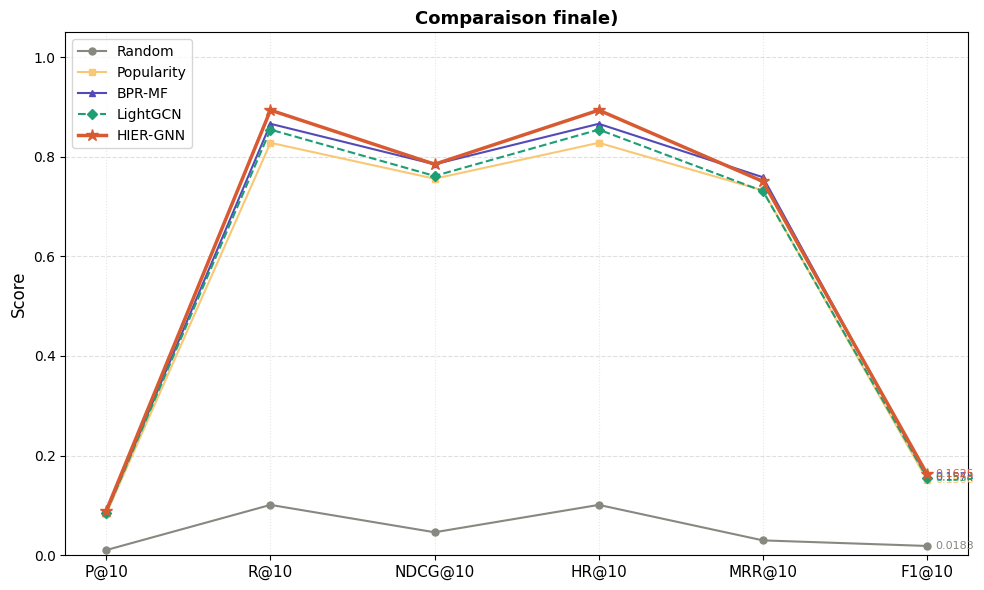

In [6]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Random', 'Popularity', 'BPR-MF', 'LightGCN', 'HIER-GNN']
metrics = {
    'P@10':    [0.0101, 0.0828, 0.0866, 0.0855, 0.0894],
    'R@10':    [0.1008, 0.8281, 0.8663, 0.8546, 0.8937],
    'NDCG@10': [0.0458, 0.7560, 0.7850, 0.7615, 0.7851],
    'HR@10':   [0.1008, 0.8281, 0.8663, 0.8546, 0.8937],
    'MRR@10':  [0.0295, 0.7325, 0.7589, 0.7310, 0.7505],
    'F1@10':   [0.0183, 0.1506, 0.1575, 0.1554, 0.1625],
}

colors     = ['#888780', '#FAC775', '#534AB7', '#1D9E75', '#D85A30']
linestyles = ['-', '-', '-', '--', '-']
linewidths = [1.5, 1.5, 1.5, 1.5, 2.5]
markers    = ['o', 's', '^', 'D', '*']
markersizes= [5, 5, 5, 5, 9]

x = np.arange(len(metrics))
metric_labels = list(metrics.keys())

fig, ax = plt.subplots(figsize=(10, 6))

for i, model in enumerate(models):
    values = [metrics[m][i] for m in metric_labels]
    ax.plot(
        x, values,
        label=model,
        color=colors[i],
        linestyle=linestyles[i],
        linewidth=linewidths[i],
        marker=markers[i],
        markersize=markersizes[i],
        zorder=3 if model == 'HIER-GNN' else 2,
    )
    # annotation du dernier point
    ax.annotate(
        f'{values[-1]:.4f}',
        xy=(x[-1], values[-1]),
        xytext=(6, 0),
        textcoords='offset points',
        fontsize=8,
        color=colors[i],
        va='center',
    )

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison finale', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, framealpha=0.8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_comparison_final.png', dpi=150)
plt.show()

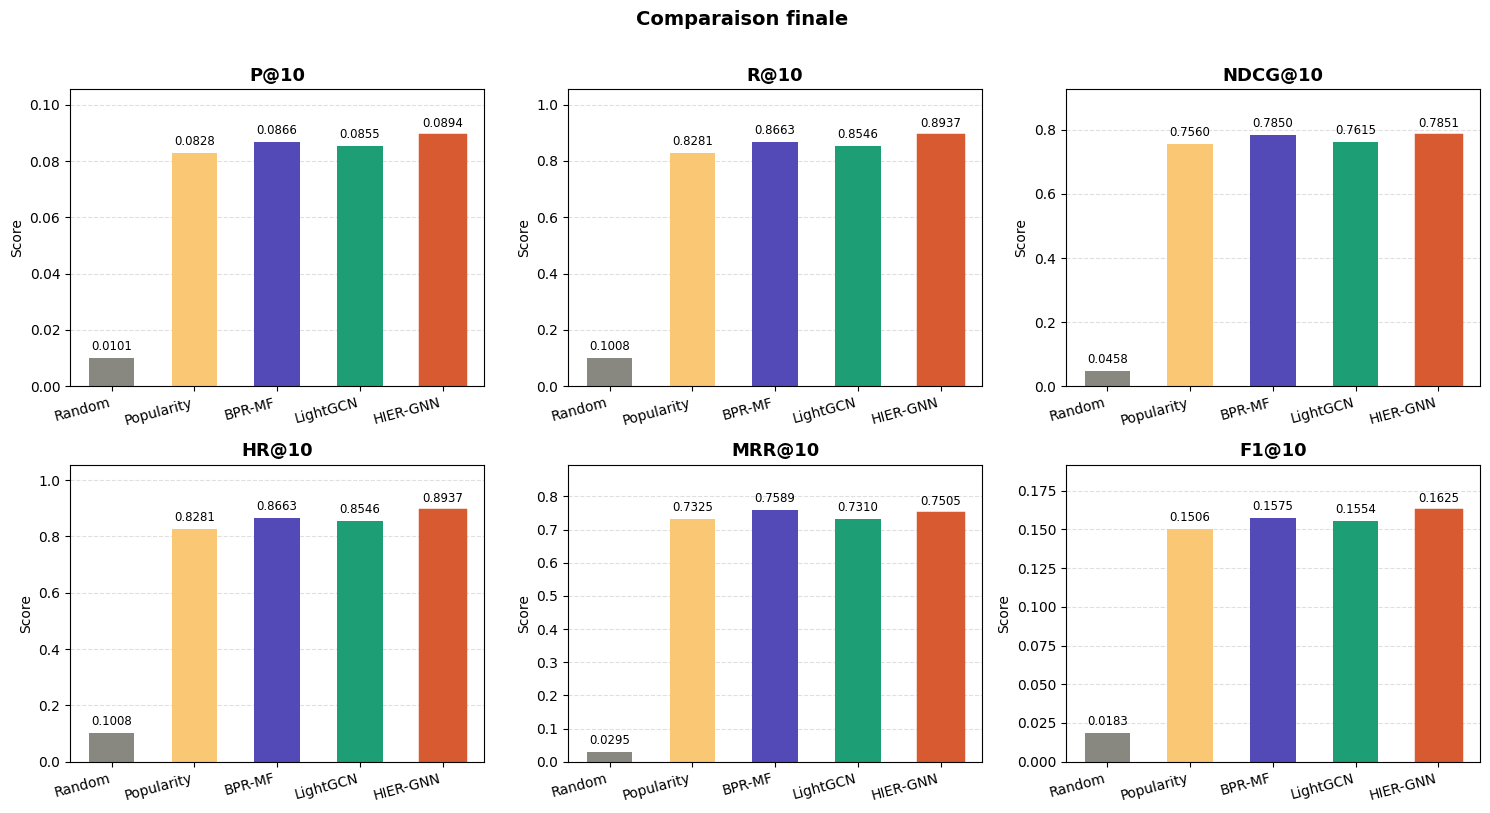

In [11]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Random', 'Popularity', 'BPR-MF', 'LightGCN', 'HIER-GNN']
metrics = {
    'P@10':    [0.0101, 0.0828, 0.0866, 0.0855, 0.0894],
    'R@10':    [0.1008, 0.8281, 0.8663, 0.8546, 0.8937],
    'NDCG@10': [0.0458, 0.7560, 0.7850, 0.7615, 0.7851],
    'HR@10':   [0.1008, 0.8281, 0.8663, 0.8546, 0.8937],
    'MRR@10':  [0.0295, 0.7325, 0.7589, 0.7310, 0.7505],
    'F1@10':   [0.0183, 0.1506, 0.1575, 0.1554, 0.1625],
}

colors     = ['#888780', '#FAC775', '#534AB7', '#1D9E75', '#D85A30']
markers    = ['o', 's', '^', 'D', '*']
markersizes= [7, 7, 7, 7, 11]

x = np.arange(len(models))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (metric, values) in enumerate(metrics.items()):
    ax = axes[idx]

    bars = ax.bar(x, values, color=colors, width=0.55, zorder=2)

    # annotation valeur sur chaque barre
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.02,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=8.5,
        )

    # encadrer la barre HIER-GNN
    best_idx = len(models) - 1
    bars[best_idx].set_edgecolor('#D85A30')
    bars[best_idx].set_linewidth(2.5)

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10, rotation=15, ha='right')
    ax.set_ylim(0, max(values) * 1.18)
    ax.set_ylabel('Score', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)

fig.suptitle('Comparaison finale ',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('baseline_comparison_per_metric.png', dpi=150, bbox_inches='tight')
plt.show()



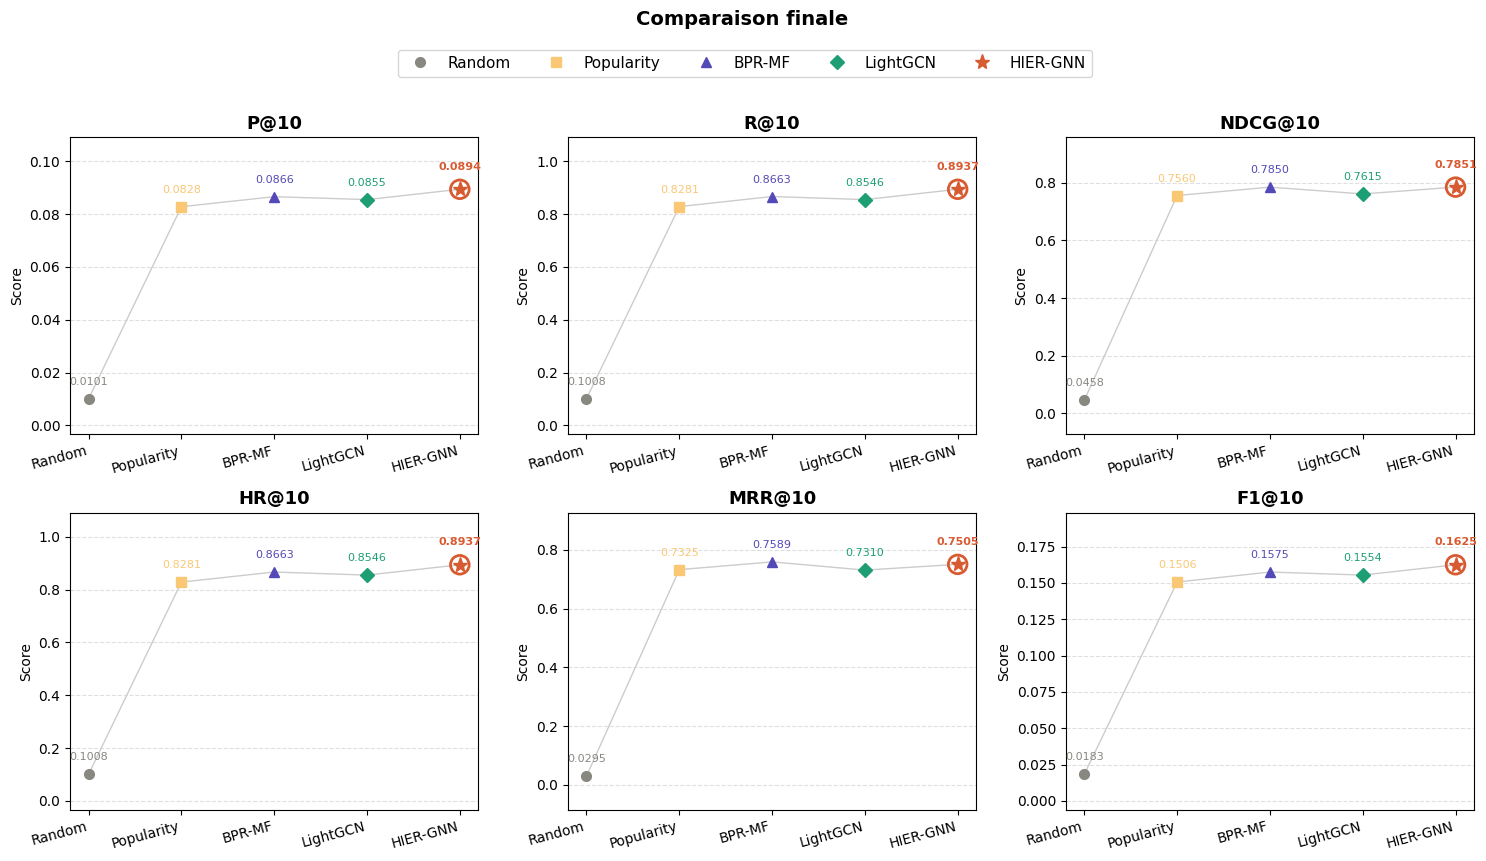

In [9]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Random', 'Popularity', 'BPR-MF', 'LightGCN', 'HIER-GNN']
metrics = {
    'P@10':    [0.0101, 0.0828, 0.0866, 0.0855, 0.0894],
    'R@10':    [0.1008, 0.8281, 0.8663, 0.8546, 0.8937],
    'NDCG@10': [0.0458, 0.7560, 0.7850, 0.7615, 0.7851],
    'HR@10':   [0.1008, 0.8281, 0.8663, 0.8546, 0.8937],
    'MRR@10':  [0.0295, 0.7325, 0.7589, 0.7310, 0.7505],
    'F1@10':   [0.0183, 0.1506, 0.1575, 0.1554, 0.1625],
}

colors     = ['#888780', '#FAC775', '#534AB7', '#1D9E75', '#D85A30']
markers    = ['o', 's', '^', 'D', '*']
markersizes= [7, 7, 7, 7, 11]
linewidths = [1.5, 1.5, 1.5, 1.5, 2.5]
linestyles = ['-', '-', '-', '--', '-']

x = np.arange(len(models))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (metric, values) in enumerate(metrics.items()):
    ax = axes[idx]

    # ligne de fond reliant tous les modèles
    ax.plot(x, values, color='#cccccc', linewidth=1, zorder=1)

    # un point par modèle
    for i, (val, model) in enumerate(zip(values, models)):
        is_hier = model == 'HIER-GNN'
        ax.plot(
            x[i], val,
            marker=markers[i],
            markersize=markersizes[i],
            color=colors[i],
            linewidth=linewidths[i],
            linestyle=linestyles[i],
            zorder=3 if is_hier else 2,
            label=model if idx == 0 else '',
        )
        # annotation valeur
        offset = max(values) * 0.03
        ax.annotate(
            f'{val:.4f}',
            xy=(x[i], val),
            xytext=(0, 10 if not is_hier else 14),
            textcoords='offset points',
            ha='center', fontsize=8,
            color=colors[i],
            fontweight='bold' if is_hier else 'normal',
        )

    # cercle de mise en évidence autour de HIER-GNN
    best_val = values[-1]
    ax.scatter(x[-1], best_val, s=180, facecolors='none',
               edgecolors='#D85A30', linewidths=2, zorder=4)

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10, rotation=15, ha='right')
    ax.set_ylim(min(values) - max(values) * 0.15, max(values) * 1.22)
    ax.set_ylabel('Score', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

# légende commune en haut
handles = [
    plt.Line2D([0], [0], color=colors[i], marker=markers[i],
               markersize=markersizes[i], linewidth=0, label=models[i])
    for i in range(len(models))
]
fig.legend(handles=handles, loc='upper center', ncol=5,
           fontsize=11, framealpha=0.8, bbox_to_anchor=(0.5, 1.03))

fig.suptitle('Comparaison finale ',
             fontsize=14, fontweight='bold', y=1.07)

plt.tight_layout()
plt.savefig('baseline_comparison_line.png', dpi=150, bbox_inches='tight')
plt.show()